# Multiverse integration

Comet includes multiverse integration methods based on the weighting schemes introduced in:

> Cantone, G. G., & Tomaselli, V. (2025). Characterisation and calibration of multiversal methods.  
> Advances in Data Analysis and Classification, 19(4), 989-1021. https://doi.org/10.1007/s11634-024-00610-9

For illustration and validation purposes, we use the "unidentified multiverse" example from the paper, which was introduced in a previous paper by Del Giudice and Gangestad (2021). https://doi.org/10.6084/m9.figshare.12089736

In [1]:
from comet.multiverse import Multiverse

forking_paths = {
    "X1": [0, 1],
    "X2": [0, 1],
    "X3": [0, 1],
    "X4": [0, 1],
    "ANTE": [0, 1],
    "MEDI": [0, 1],
    "COLL": [0, 1],
    "CONF": [0, 1],
}

def analysis_template():
    import comet
    import statsmodels.formula.api as smf

    data = comet.utils.load_example("cantone")
    
    # Build composite predictor
    data["pred"] = 0.0
    if {{X1}}:
        data["pred"] += data["BM1"]
    if {{X2}}:
        data["pred"] += data["BM2"]
    if {{X3}}:
        data["pred"] += data["BM3"]
    if {{X4}}:
        data["pred"] += data["BM4"]

    # Build covariates
    cov = ""
    if {{ANTE}}:
        cov += " + genotype"
    if {{MEDI}}:
        cov += " + pain"
    if {{COLL}}:
        cov += " + fatigue"
    if {{CONF}}:
        cov += " + age"

    # Regression model
    formula = "depression ~ pred" + cov
    fit_res = smf.ols(formula=formula, data=data).fit()

    beta_raw = float(fit_res.params["pred"])
    sd_y = float(data["depression"].std())
    sd_x = float(data["pred"].std())
    beta_std = beta_raw * (sd_x / sd_y)

    out = {
        "formula": formula,
        "beta": float(beta_std),
        "beta_raw": float(beta_raw),
        "p_value": float(fit_res.pvalues["pred"]),
    }

    comet.utils.save_universe_results(out)

config = {
    "remove": [
        [{"X1": 0}, {"X2": 0}, {"X3": 0}, {"X4": 0}],
    ]
}

mverse = Multiverse(name="example_mv_integration")
mverse.create(analysis_template, forking_paths, config)
mverse.summary()
mverse.run(parallel=16)

Removed 16 out of 256 universes:


,Universe,Decision 1,Value 1,Decision 2,Value 2,Decision 3,Value 3,Decision 4,Value 4,Decision 5,Value 5,Decision 6,Value 6,Decision 7,Value 7,Decision 8,Value 8
0,Universe_1,X1,0,X2,0,X3,0,X4,1,ANTE,0,MEDI,0,COLL,0,CONF,0
1,Universe_2,X1,0,X2,0,X3,0,X4,1,ANTE,0,MEDI,0,COLL,0,CONF,1
2,Universe_3,X1,0,X2,0,X3,0,X4,1,ANTE,0,MEDI,0,COLL,1,CONF,0
3,Universe_4,X1,0,X2,0,X3,0,X4,1,ANTE,0,MEDI,0,COLL,1,CONF,1
4,Universe_5,X1,0,X2,0,X3,0,X4,1,ANTE,0,MEDI,1,COLL,0,CONF,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,Universe_236,X1,1,X2,1,X3,1,X4,1,ANTE,1,MEDI,0,COLL,1,CONF,1
236,Universe_237,X1,1,X2,1,X3,1,X4,1,ANTE,1,MEDI,1,COLL,0,CONF,0
237,Universe_238,X1,1,X2,1,X3,1,X4,1,ANTE,1,MEDI,1,COLL,0,CONF,1
238,Universe_239,X1,1,X2,1,X3,1,X4,1,ANTE,1,MEDI,1,COLL,1,CONF,0


Starting multiverse analysis for all universes...


Performing multiverse analysis::   0%|          | 0/240 [00:00<?, ?it/s]

The multiverse analysis completed without any errors.


We visualise the multiverse results:

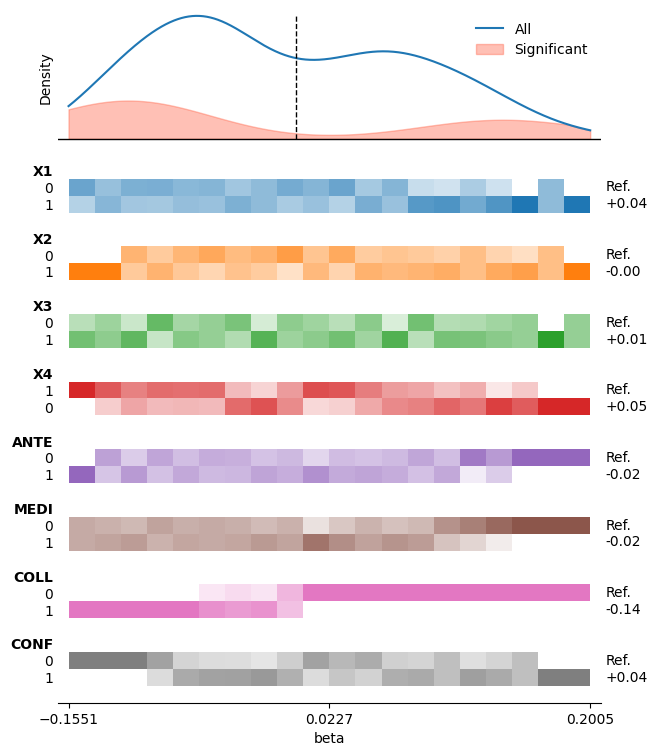

In [2]:
mverse.multiverse_plot(measure="beta", n_bins=20, sig_col="p_value", baseline=0, figsize=(7,9))

Comet currently contains two methods for integrating over the multiverse:

`uniform`
- All universes are weighted equally (the estimate is just the plain mean/median across universes). This corresponds to the density function as plotted in the multiverse plot above.

`mli` (Maximum Local Influence)
- Each universe is compared with its nearest neighbours (specifications differing by a single decision). Universes whose estimate barely changes when one decision is flipped are weighted more, down-weighting results that hinge on a single arbitrary choice.

As an example, we can use the `.integrate()` method to simply get an integrated measure over all universes. For example, using uniform weighting and mean aggregation:

In [3]:
estimate, weights = mverse.integrate(measure="beta", method="uniform", type="mean")
print(f"Mean beta: {estimate:.4f}")

Mean beta: -0.0066


We can also use the `compare_integration` and `plot_integration` convenience functions to get a summary for both integration methods.

In [4]:
table, weights = mverse.compare_integration(measure="beta", true_value=0.2)
table

,Scheme,median,mean,gini_w,err_median,err_mean
0,Uniform,-0.0210,-0.0066,0.000,0.221,0.207
1,MLI,-0.0328,-0.0144,0.243,0.233,0.214


The columns are, for each weighting scheme:

- `median` / `mean`: the integrated estimate (weighted median/mean of `beta`)
- `gini_w`: how concentrated the weights are (0 = all equal, → 1 = dominated by a few universes).

If `true_value` is passed, additional `err_*` columns give the absolute error of each estimate against it. Usually, this is not available in real multiverses, but we can include it here as we have the ground truth from the simulation.

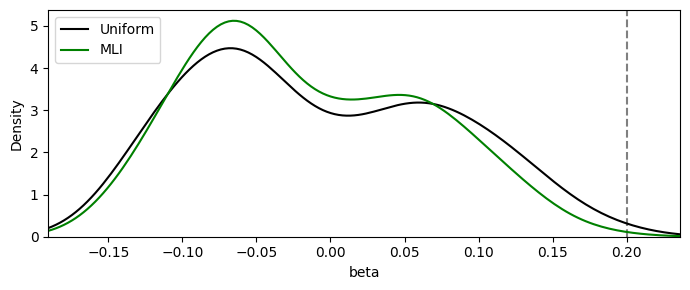

In [5]:
mverse.plot_integration(measure="beta", weights=weights, true_value=0.2)